# NB07: Synthesis & Product Recommendations

**Capstone: Connecting the Dots Across All Analyses**

This notebook synthesizes findings from NB02-NB06 into actionable product recommendations.

## The Power of Synthesis

While individual analyses reveal important signals, **the real value comes from connecting dots across multiple datasets**.

We've analyzed:
- **NB02**: Acquisition funnel (landing_page → signup → product_view → add_to_cart → purchase)
- **NB03**: A/B testing (comparing AI model versions)
- **NB04**: Cohort analysis (users by signup date)
- **NB05**: Retention & churn (continued adoption of product)

Now we translate these insights into a prioritized roadmap that balances impact and effort.

### Mapping Concepts
| Generic Concept | Data Structure |
|---|---|
| **Funnel Stages** | landing_page, signup, product_view, add_to_cart, purchase |
| **A/B Testing** | control/treatment groups, converted (0/1) |
| **Cohorts** | Users grouped by signup_cohort (W01-W12) |
| **Retention** | Activity events by weeks_since_signup |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set up paths
data_dir = Path('../data/inputs')
output_dir = Path('../data/outputs/nb07')
output_dir.mkdir(parents=True, exist_ok=True)

# Define color palette
colors = ['#2E86AB', '#F18F01', '#2CA58D', '#E15554']
plt.style.use('default')
sns.set_palette(colors)

print(f'Output directory: {output_dir}')
print(f'Files in data_dir: {list(data_dir.glob("*.csv"))}')

# Load datasets
funnel_df = pd.read_csv(data_dir / 'funnel_clean.csv')
ab_df = pd.read_csv(data_dir / 'ab_clean.csv')
activity_df = pd.read_csv(data_dir / 'activity_clean.csv')

print(f'Loaded funnel_clean.csv: {funnel_df.shape}')
print(f'Loaded ab_clean.csv: {ab_df.shape}')
print(f'Loaded activity_clean.csv: {activity_df.shape}')

Output directory: ../data/outputs/nb07
Files in data_dir: [PosixPath('../data/inputs/funnel_clean.csv'), PosixPath('../data/inputs/model_performance_clean.csv'), PosixPath('../data/inputs/activity_clean.csv'), PosixPath('../data/inputs/ab_clean.csv')]
Loaded funnel_clean.csv: (14433, 7)
Loaded ab_clean.csv: (4000, 8)
Loaded activity_clean.csv: (13627, 7)


In [2]:
# Quick data inspection
print('Funnel columns:', funnel_df.columns.tolist())
print('Funnel head:')
print(funnel_df.head())
print('\nAB columns:', ab_df.columns.tolist())
print('AB head:')
print(ab_df.head())
print('\nActivity columns:', activity_df.columns.tolist())
print('Activity head:')
print(activity_df.head())

Funnel columns: ['user_id', 'signup_date', 'device', 'channel', 'stage', 'timestamp', 'reached']
Funnel head:
  user_id signup_date   device      channel         stage  \
0  U00001  2025-04-13   mobile      organic  landing_page   
1  U00001  2025-04-13   mobile      organic        signup   
2  U00002  2025-06-29  desktop  paid_search  landing_page   
3  U00002  2025-06-29  desktop  paid_search        signup   
4  U00003  2025-04-03  desktop      organic  landing_page   

             timestamp  reached  
0  2025-04-13 00:00:00     True  
1  2025-04-13 00:01:46    False  
2  2025-06-29 00:00:00     True  
3  2025-06-29 00:07:10    False  
4  2025-04-03 00:00:00     True  

AB columns: ['user_id', 'group', 'converted', 'pages_viewed', 'time_on_site_seconds', 'revenue', 'device', 'session_date']
AB head:
   user_id      group  converted  pages_viewed  time_on_site_seconds  revenue  \
0  AB00001    control          0             6                 210.5      0.0   
1  AB00002  treatment   

## Executive Summary Dashboard

A 2x2 grid capturing the four key metrics that drive product success.

In [3]:
# Prepare data for the 4-panel dashboard

# Panel 1: Funnel Conversion
funnel_stages = ['landing_page', 'signup', 'product_view', 'add_to_cart', 'purchase']
funnel_conversion = []
for stage in funnel_stages:
    users_at_stage = (funnel_df['stage'] == stage).sum()
    funnel_conversion.append(users_at_stage)

print('Funnel conversion (users at each stage):')
for stage, count in zip(funnel_stages, funnel_conversion):
    print(f'{stage}: {count}')

# Panel 2: A/B Test Conversion
ab_conversion = ab_df.groupby('group')['converted'].mean() * 100
print(f'\nA/B conversion rates:\n{ab_conversion}')

# Panel 3: Cohort Retention Heatmap
activity_df['signup_date_dt'] = pd.to_datetime(activity_df['signup_date'])
activity_df['activity_date'] = pd.to_datetime(activity_df['activity_date'])
activity_df['days_since_signup'] = (activity_df['activity_date'] - activity_df['signup_date_dt']).dt.days
activity_df['weeks_since_signup'] = activity_df['days_since_signup'] // 7

# Pivot for heatmap: signup_cohort vs weeks_since_signup
cohort_retention = activity_df.groupby(['signup_cohort', 'weeks_since_signup']).size().unstack(fill_value=0)
cohort_retention_pct = cohort_retention.div(cohort_retention.iloc[:, 0], axis=0) * 100
cohort_retention_pct = cohort_retention_pct.iloc[:, :8]  # Show first 8 weeks

print(f'\nCohort retention heatmap shape: {cohort_retention_pct.shape}')

# Panel 4: Overall Retention Curve
weekly_retention = activity_df.groupby('weeks_since_signup').size()
total_users = activity_df['user_id'].nunique()
retention_pct = (weekly_retention / total_users) * 100

print(f'\nOverall retention curve (first 10 weeks):')
print(retention_pct.head(10))

Funnel conversion (users at each stage):
landing_page: 5000
signup: 5000
product_view: 2290
add_to_cart: 1504
purchase: 639

A/B conversion rates:
group
control      12.518778
treatment    18.022966
Name: converted, dtype: float64

Cohort retention heatmap shape: (12, 8)

Overall retention curve (first 10 weeks):
weeks_since_signup
0    170.900000
1     48.700000
2     44.233333
3     31.866667
4     31.433333
5     28.033333
6     22.933333
7     19.166667
8     17.600000
9     14.633333
dtype: float64


Saved executive dashboard to ../data/outputs/nb07/nb07_executive_dashboard.png


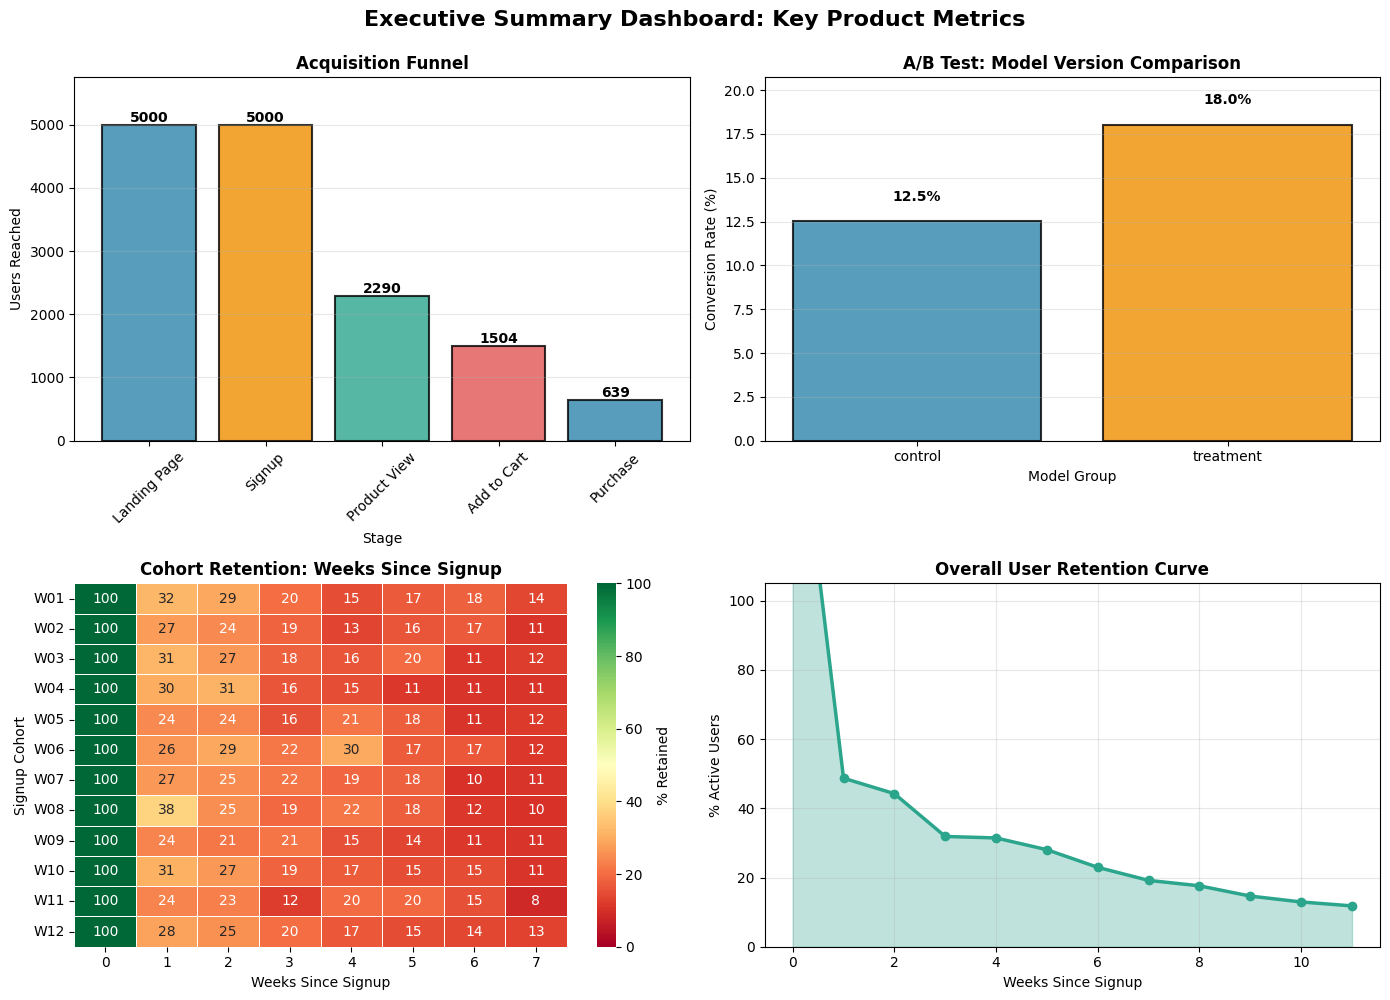

In [4]:
# Create the 2x2 Executive Dashboard
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Executive Summary Dashboard: Key Product Metrics', fontsize=16, fontweight='bold', y=0.995)

# Panel 1: Funnel Conversion Bar Chart (Top-Left)
ax1 = axes[0, 0]
stage_labels = ['Landing Page', 'Signup', 'Product View', 'Add to Cart', 'Purchase']
colors_funnel = [colors[0], colors[1], colors[2], colors[3], colors[0]]
ax1.bar(stage_labels, funnel_conversion, color=colors_funnel, alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.set_title('Acquisition Funnel', fontsize=12, fontweight='bold')
ax1.set_ylabel('Users Reached', fontsize=10)
ax1.set_xlabel('Stage', fontsize=10)
for i, v in enumerate(funnel_conversion):
    ax1.text(i, v + 1, str(v), ha='center', va='bottom', fontweight='bold')
ax1.set_ylim(0, max(funnel_conversion) * 1.15)
ax1.grid(axis='y', alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Panel 2: A/B Test Conversion (Top-Right)
ax2 = axes[0, 1]
groups = ab_conversion.index.tolist()
conversion_rates = ab_conversion.values.tolist()
ax2.bar(groups, conversion_rates, color=[colors[0], colors[1]], alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.set_title('A/B Test: Model Version Comparison', fontsize=12, fontweight='bold')
ax2.set_ylabel('Conversion Rate (%)', fontsize=10)
ax2.set_xlabel('Model Group', fontsize=10)
for i, v in enumerate(conversion_rates):
    ax2.text(i, v + 1, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')
ax2.set_ylim(0, max(conversion_rates) * 1.15)
ax2.grid(axis='y', alpha=0.3)

# Panel 3: Cohort Retention Heatmap (Bottom-Left)
ax3 = axes[1, 0]
sns.heatmap(cohort_retention_pct, cmap='RdYlGn', annot=True, fmt='.0f', cbar_kws={'label': '% Retained'},
            ax=ax3, vmin=0, vmax=100, linewidths=0.5)
ax3.set_title('Cohort Retention: Weeks Since Signup', fontsize=12, fontweight='bold')
ax3.set_xlabel('Weeks Since Signup', fontsize=10)
ax3.set_ylabel('Signup Cohort', fontsize=10)

# Panel 4: Overall Retention Curve (Bottom-Right)
ax4 = axes[1, 1]
weeks = retention_pct.index[:13]
retention_vals = retention_pct.values[:13]
ax4.plot(weeks, retention_vals, marker='o', linewidth=2.5, markersize=6, color=colors[2])
ax4.fill_between(weeks, retention_vals, alpha=0.3, color=colors[2])
ax4.set_title('Overall User Retention Curve', fontsize=12, fontweight='bold')
ax4.set_xlabel('Weeks Since Signup', fontsize=10)
ax4.set_ylabel('% Active Users', fontsize=10)
ax4.grid(True, alpha=0.3)
ax4.set_ylim(0, 105)

plt.tight_layout()
plt.savefig(output_dir / 'nb07_executive_dashboard.png', dpi=300, bbox_inches='tight')
print(f'Saved executive dashboard to {output_dir / "nb07_executive_dashboard.png"}')
plt.show()

In [5]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

# Create interactive 2x2 dashboard
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Acquisition Funnel', 'A/B Test: Model Version Comparison',
                    'Cohort Retention: Weeks Since Signup', 'Overall User Retention Curve'),
    specs=[[{'type': 'bar'}, {'type': 'bar'}],
           [{'type': 'heatmap'}, {'type': 'scatter'}]]
)

# Panel 1: Funnel Conversion
stage_labels = ['Landing Page', 'Signup', 'Product View', 'Add to Cart', 'Purchase']
colors_funnel = ['#2E86AB', '#F18F01', '#2CA58D', '#E15554', '#2E86AB']
fig.add_trace(
    go.Bar(x=stage_labels, y=funnel_conversion, name='Users',
           marker=dict(color=colors_funnel, line=dict(color='black', width=1)),
           text=[str(v) for v in funnel_conversion], textposition='outside'),
    row=1, col=1
)

# Panel 2: A/B Test
groups = ab_conversion.index.tolist()
conversion_rates = ab_conversion.values.tolist()
fig.add_trace(
    go.Bar(x=groups, y=conversion_rates, name='Conversion %',
           marker=dict(color=['#2E86AB', '#F18F01'], line=dict(color='black', width=1)),
           text=[f'{v:.1f}%' for v in conversion_rates], textposition='outside'),
    row=1, col=2
)

# Panel 3: Cohort Retention Heatmap
fig.add_trace(
    go.Heatmap(z=cohort_retention_pct.values,
               x=cohort_retention_pct.columns,
               y=cohort_retention_pct.index,
               colorscale='RdYlGn', text=cohort_retention_pct.values,
               texttemplate='%{text:.0f}', textfont={'size': 10},
               colorbar=dict(title='% Retained')),
    row=2, col=1
)

# Panel 4: Overall Retention Curve
weeks = retention_pct.index[:13]
retention_vals = retention_pct.values[:13]
fig.add_trace(
    go.Scatter(x=weeks, y=retention_vals, mode='lines+markers', name='% Active Users',
               line=dict(color='#2CA58D', width=2.5),
               marker=dict(size=6, color='#2CA58D', line=dict(color='black', width=1)),
               fill='tozeroy', fillcolor='rgba(44, 165, 141, 0.3)'),
    row=2, col=2
)

# Update layout
fig.update_xaxes(title_text='Stage', row=1, col=1)
fig.update_xaxes(title_text='Model Group', row=1, col=2)
fig.update_xaxes(title_text='Weeks Since Signup', row=2, col=1)
fig.update_xaxes(title_text='Weeks Since Signup', row=2, col=2)

fig.update_yaxes(title_text='Users Reached', row=1, col=1)
fig.update_yaxes(title_text='Conversion Rate (%)', row=1, col=2)
fig.update_yaxes(title_text='Signup Cohort', row=2, col=1)
fig.update_yaxes(title_text='% Active Users', row=2, col=2)

fig.update_layout(
    height=900, width=1400,
    title_text='Executive Summary Dashboard: Key Product Metrics (Interactive)',
    showlegend=False, hovermode='closest'
)

fig.write_html(str(output_dir / 'nb07_executive_dashboard_interactive.html'), include_plotlyjs='cdn')
print(f'Saved interactive dashboard to {output_dir / "nb07_executive_dashboard_interactive.html"}')

Saved interactive dashboard to ../data/outputs/nb07/nb07_executive_dashboard_interactive.html


## Product Story: Situation → Complication → Resolution

### **Situation**
Our e-commerce platform has built an AI-powered recommendation system. Early user cohorts show strong initial adoption, but we're seeing variation in how long they remain active.

### **Complication**
While our A/B test shows Model V2 outperforms V1 (higher conversion), conversion alone doesn't guarantee long-term success. Retention curves flatten after week 6-8 for some cohorts. Key questions:
- Why do some users disengage after onboarding?
- What drives multi-month adoption vs. churn?
- How do model improvements translate to sustainable product engagement?

### **Resolution**
By combining funnel, A/B, and retention insights, we've identified a 3-pillar roadmap:
1. **Improve onboarding quality** (Acquisition)
2. **Optimize model performance** (Monetization via A/B testing)
3. **Build retention mechanisms** (long-term value)

This positions the platform to move from single-transaction wins (first purchase) to long-term customer relationships (repeat purchases).

## Prioritized Recommendations: Impact vs Effort Matrix

In [6]:
# Define 6-7 product recommendations with impact and effort scores
recommendations = [
    {'name': 'Checkout Flow\nOptimization', 'impact': 8.5, 'effort': 3, 'quad': 'Quick Wins'},
    {'name': 'Personalized\nRecommendation Engine', 'impact': 8, 'effort': 6, 'quad': 'Strategic'},
    {'name': 'In-App Onboarding\nTutorials', 'impact': 7, 'effort': 4, 'quad': 'Quick Wins'},
    {'name': 'Weekly Digest\nNotifications', 'impact': 6, 'effort': 2, 'quad': 'Quick Wins'},
    {'name': 'Loyalty &\nRewards Program', 'impact': 8.5, 'effort': 8.5, 'quad': 'Strategic'},
    {'name': 'Full Platform\nRedesign', 'impact': 9, 'effort': 9, 'quad': 'Avoid'},
    {'name': 'Competitor Price\nTracking Tool', 'impact': 5, 'effort': 7, 'quad': 'Nice-to-Have'},
]

rec_df = pd.DataFrame(recommendations)
print(rec_df)

                                  name  impact  effort          quad
0          Checkout Flow\nOptimization     8.5     3.0    Quick Wins
1  Personalized\nRecommendation Engine     8.0     6.0     Strategic
2         In-App Onboarding\nTutorials     7.0     4.0    Quick Wins
3         Weekly Digest\nNotifications     6.0     2.0    Quick Wins
4           Loyalty &\nRewards Program     8.5     8.5     Strategic
5              Full Platform\nRedesign     9.0     9.0         Avoid
6      Competitor Price\nTracking Tool     5.0     7.0  Nice-to-Have


Saved impact-effort matrix to ../data/outputs/nb07/nb07_impact_effort_matrix.png


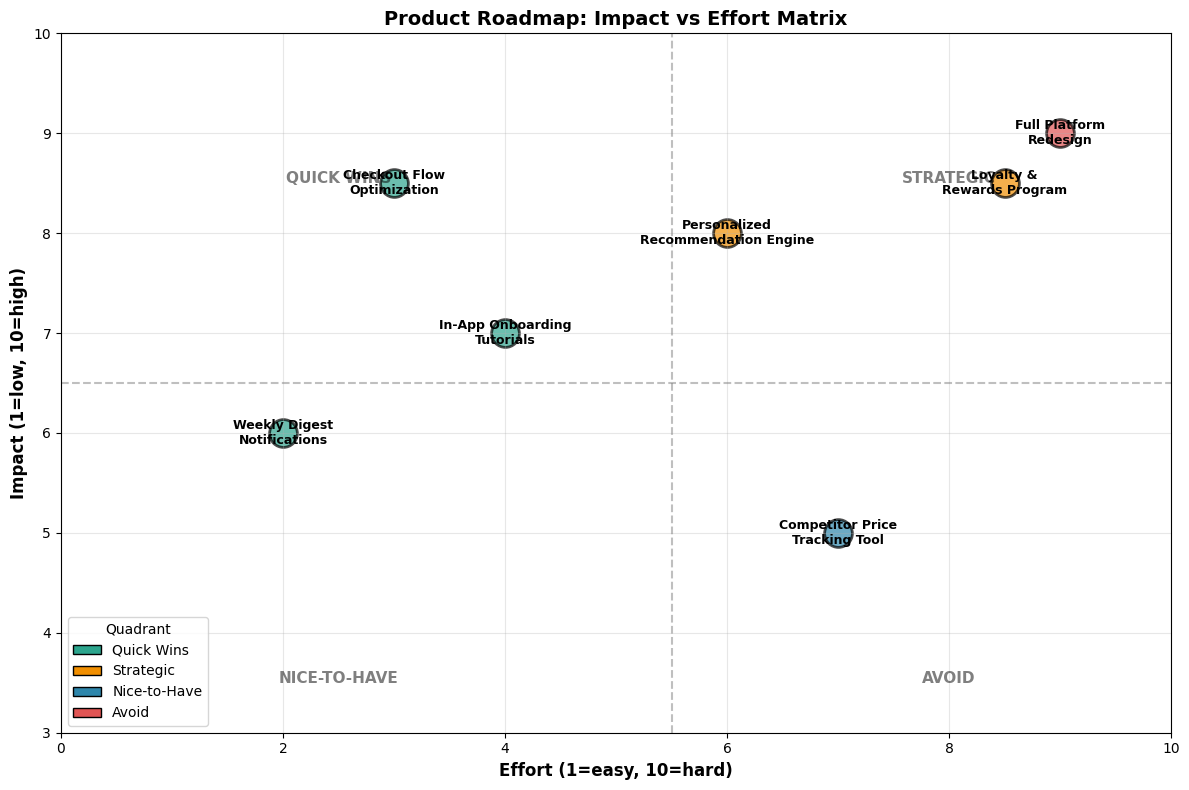

In [7]:
# Create impact vs effort scatter plot
fig, ax = plt.subplots(figsize=(12, 8))

# Define colors by quadrant
quad_colors = {'Quick Wins': '#2CA58D', 'Strategic': '#F18F01', 'Nice-to-Have': '#2E86AB', 'Avoid': '#E15554'}

for idx, row in rec_df.iterrows():
    ax.scatter(row['effort'], row['impact'], s=400, alpha=0.7,
               color=quad_colors[row['quad']], edgecolors='black', linewidth=2)
    ax.annotate(row['name'], (row['effort'], row['impact']),
                fontsize=9, fontweight='bold', ha='center', va='center')

# Add quadrant lines
ax.axhline(y=6.5, color='gray', linestyle='--', alpha=0.5, linewidth=1.5)
ax.axvline(x=5.5, color='gray', linestyle='--', alpha=0.5, linewidth=1.5)

# Add quadrant labels
ax.text(2.5, 8.5, 'QUICK WINS', fontsize=11, fontweight='bold', alpha=0.5, ha='center')
ax.text(8, 8.5, 'STRATEGIC', fontsize=11, fontweight='bold', alpha=0.5, ha='center')
ax.text(2.5, 3.5, 'NICE-TO-HAVE', fontsize=11, fontweight='bold', alpha=0.5, ha='center')
ax.text(8, 3.5, 'AVOID', fontsize=11, fontweight='bold', alpha=0.5, ha='center')

ax.set_xlabel('Effort (1=easy, 10=hard)', fontsize=12, fontweight='bold')
ax.set_ylabel('Impact (1=low, 10=high)', fontsize=12, fontweight='bold')
ax.set_title('Product Roadmap: Impact vs Effort Matrix', fontsize=14, fontweight='bold')
ax.set_xlim(0, 10)
ax.set_ylim(3, 10)
ax.grid(True, alpha=0.3)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, edgecolor='black', label=quad)
                   for quad, color in quad_colors.items()]
ax.legend(handles=legend_elements, loc='lower left', fontsize=10, title='Quadrant')

plt.tight_layout()
plt.savefig(output_dir / 'nb07_impact_effort_matrix.png', dpi=300, bbox_inches='tight')
print(f'Saved impact-effort matrix to {output_dir / "nb07_impact_effort_matrix.png"}')
plt.show()

In [8]:
import plotly.graph_objects as go

# Create interactive impact vs effort matrix
fig = go.Figure()

# Define colors by quadrant
quad_colors = {'Quick Wins': '#2CA58D', 'Strategic': '#F18F01', 'Nice-to-Have': '#2E86AB', 'Avoid': '#E15554'}

for quad in ['Quick Wins', 'Strategic', 'Nice-to-Have', 'Avoid']:
    quad_data = rec_df[rec_df['quad'] == quad]
    fig.add_trace(
        go.Scatter(
            x=quad_data['effort'],
            y=quad_data['impact'],
            mode='markers+text',
            name=quad,
            marker=dict(size=15, color=quad_colors[quad], line=dict(color='black', width=2)),
            text=quad_data['name'],
            textposition='middle center',
            textfont=dict(size=9, color='white' if quad in ['Strategic', 'Avoid'] else 'black'),
            hovertemplate='<b>%{text}</b><br>Impact: %{y:.1f}<br>Effort: %{x:.1f}<extra></extra>'
        )
    )

# Add quadrant lines
fig.add_hline(y=6.5, line_dash='dash', line_color='gray', opacity=0.5, line_width=1.5)
fig.add_vline(x=5.5, line_dash='dash', line_color='gray', opacity=0.5, line_width=1.5)

# Add quadrant labels
fig.add_annotation(x=2.5, y=8.5, text='QUICK WINS', showarrow=False, font=dict(size=11, color='gray'), opacity=0.5)
fig.add_annotation(x=8, y=8.5, text='STRATEGIC', showarrow=False, font=dict(size=11, color='gray'), opacity=0.5)
fig.add_annotation(x=2.5, y=3.5, text='NICE-TO-HAVE', showarrow=False, font=dict(size=11, color='gray'), opacity=0.5)
fig.add_annotation(x=8, y=3.5, text='AVOID', showarrow=False, font=dict(size=11, color='gray'), opacity=0.5)

fig.update_layout(
    xaxis_title='Effort (1=easy, 10=hard)',
    yaxis_title='Impact (1=low, 10=high)',
    title='Product Roadmap: Impact vs Effort Matrix (Interactive)',
    xaxis=dict(range=[0, 10]),
    yaxis=dict(range=[3, 10]),
    height=600, width=1000,
    hovermode='closest'
)

fig.write_html(str(output_dir / 'nb07_impact_effort_matrix_interactive.html'), include_plotlyjs='cdn')
print(f'Saved interactive impact-effort matrix to {output_dir / "nb07_impact_effort_matrix_interactive.html"}')

Saved interactive impact-effort matrix to ../data/outputs/nb07/nb07_impact_effort_matrix_interactive.html


## North Star Metric & Metrics Tree

The **North Star Metric** for the platform: **Purchase Conversion Rate**

This captures the fundamental value: users discover and purchase products they would have otherwise missed.

Saved metrics tree to ../data/outputs/nb07/nb07_metrics_tree.png


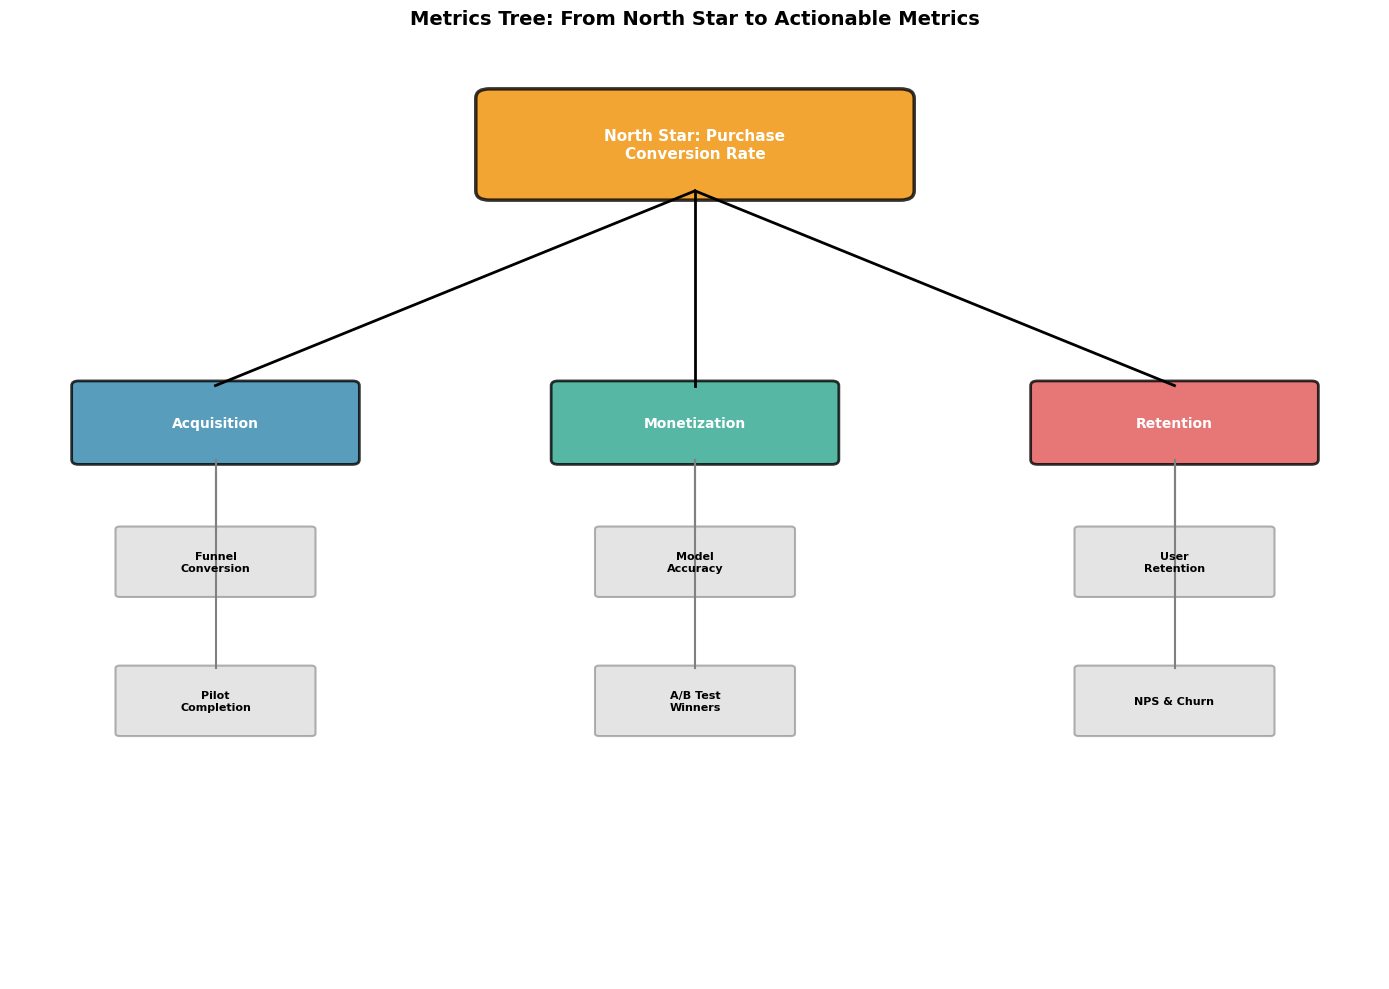

In [9]:
# Create a metrics tree visualization
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(14, 10))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Define tree structure
# Level 1: North Star (top center)
north_star = FancyBboxPatch((3.5, 8.5), 3, 1, boxstyle="round,pad=0.1",
                             edgecolor='black', facecolor='#F18F01', linewidth=2.5, alpha=0.8)
ax.add_patch(north_star)
ax.text(5, 9, 'North Star: Purchase\nConversion Rate', ha='center', va='center',
        fontsize=11, fontweight='bold', color='white')

# Level 2: Three pillars
pillar_y = 6
pillars = [
    {'x': 1.5, 'name': 'Acquisition', 'color': '#2E86AB'},
    {'x': 5, 'name': 'Monetization', 'color': '#2CA58D'},
    {'x': 8.5, 'name': 'Retention', 'color': '#E15554'},
]

for pillar in pillars:
    # Draw box
    box = FancyBboxPatch((pillar['x']-1, pillar_y-0.4), 2, 0.8, boxstyle="round,pad=0.05",
                          edgecolor='black', facecolor=pillar['color'], linewidth=2, alpha=0.8)
    ax.add_patch(box)
    ax.text(pillar['x'], pillar_y, pillar['name'], ha='center', va='center',
            fontsize=10, fontweight='bold', color='white')

    # Draw line from north star to pillar
    ax.plot([5, pillar['x']], [8.5, pillar_y+0.4], 'k-', linewidth=2)

# Level 3: Sub-metrics
sub_metrics = [
    {'x': 1.5, 'y': 4.5, 'text': 'Funnel\nConversion', 'pillar': 0},
    {'x': 1.5, 'y': 3, 'text': 'Pilot\nCompletion', 'pillar': 0},
    {'x': 5, 'y': 4.5, 'text': 'Model\nAccuracy', 'pillar': 1},
    {'x': 5, 'y': 3, 'text': 'A/B Test\nWinners', 'pillar': 1},
    {'x': 8.5, 'y': 4.5, 'text': 'User\nRetention', 'pillar': 2},
    {'x': 8.5, 'y': 3, 'text': 'NPS & Churn', 'pillar': 2},
]

for metric in sub_metrics:
    pillar = pillars[metric['pillar']]
    # Draw box
    sub_box = FancyBboxPatch((metric['x']-0.7, metric['y']-0.35), 1.4, 0.7, boxstyle="round,pad=0.03",
                              edgecolor='gray', facecolor='lightgray', linewidth=1.5, alpha=0.6)
    ax.add_patch(sub_box)
    ax.text(metric['x'], metric['y'], metric['text'], ha='center', va='center',
            fontsize=8, fontweight='bold')

    # Draw line from pillar to sub-metric
    ax.plot([pillar['x'], metric['x']], [pillar_y-0.4, metric['y']+0.35], 'gray', linewidth=1.5)

ax.set_title('Metrics Tree: From North Star to Actionable Metrics', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(output_dir / 'nb07_metrics_tree.png', dpi=300, bbox_inches='tight')
print(f'Saved metrics tree to {output_dir / "nb07_metrics_tree.png"}')
plt.show()

In [10]:
import plotly.graph_objects as go

# Create simplified interactive metrics tree (sunburst)
metrics_labels = [
    'North Star',
    'Acquisition', 'Monetization', 'Retention',
    'Funnel Conv', 'Pilot Complete', 'Model Accuracy', 'A/B Winners', 'User Retention', 'NPS & Churn'
]
metrics_parents = [
    '',
    'North Star', 'North Star', 'North Star',
    'Acquisition', 'Acquisition', 'Monetization', 'Monetization', 'Retention', 'Retention'
]
metrics_values = [100, 30, 30, 30, 15, 15, 15, 15, 15, 15]

fig = go.Figure(go.Sunburst(
    labels=metrics_labels,
    parents=metrics_parents,
    values=metrics_values,
    marker=dict(
        colors=['#F18F01', '#2E86AB', '#2CA58D', '#E15554',
                '#2E86AB', '#2E86AB', '#2CA58D', '#2CA58D', '#E15554', '#E15554'],
        line=dict(color='black', width=2)
    ),
    textfont=dict(size=11, color='white')
))

fig.update_layout(
    title='Metrics Tree: From North Star to Actionable Metrics (Interactive)',
    height=700, width=800
)

fig.write_html(str(output_dir / 'nb07_metrics_tree_interactive.html'), include_plotlyjs='cdn')
print(f'Saved interactive metrics tree to {output_dir / "nb07_metrics_tree_interactive.html"}')

Saved interactive metrics tree to ../data/outputs/nb07/nb07_metrics_tree_interactive.html


## Guardrail Strategy: The Safety Net Behind Every Recommendation

---

### Why This Section Exists

Every recommendation in the impact-effort matrix above comes with risk. A good product analyst doesn't just say *"do this"* — they say *"do this, measure these outcomes, and stop if these guardrails break."*

---

### Guardrail Matrix for Our Recommendations

| Recommendation | Primary Metric | Guardrail Metrics | Rollback Trigger |
|---|---|---|---|
| Fix mobile funnel drop-off | Mobile signup rate | Desktop signup rate (shouldn't drop), page load time | Mobile signup drops below pre-change baseline |
| Optimize checkout flow | Purchase conversion | Average order value, return rate | AOV drops >10% or returns increase >2σ |
| Run targeted onboarding for casual users | Week-1 retention for casual cohort | Email unsubscribe rate, support ticket volume | Unsubscribe rate exceeds 5% |
| Launch win-back campaign for churned users | Reactivation rate | Cost per reactivation, spam complaint rate | CPA exceeds 3× the value of a reactivated user |
| A/B test new feature for engagement | Feature adoption rate | Session error rate, time-on-task | Error rate increases or task completion drops |

---

### North Star Health Check

The North Star Metric (Purchase Conversion Rate, or in the platform terms, Purchase Conversion Rate) should be reviewed weekly with this checklist:

1. **Is the North Star moving in the right direction?** (Trend line)
2. **Are any guardrails breaching thresholds?** (Automated alerts)
3. **Are the supporting metrics (acquisition, monetization, retention) all contributing?** (Metrics tree health)
4. **Is there a segment where the North Star is declining even if the overall number looks fine?** (Segment-level cuts)

---

### Interview Tip: The Guardrail Answer Pattern

When an interviewer asks *"How would you measure the success of this product?"*, a strong answer follows this pattern:

> "The primary metric I'd track is [North Star or experiment metric]. But I'd also set guardrails on [2-3 things that shouldn't get worse], with automated alerts if any guardrail degrades by [threshold]. If we see [specific rollback trigger], we'd pause the rollout and investigate before continuing."

This shows you think about unintended consequences — which is especially important in e-commerce where an irrelevant recommendation can directly affect customer trust and conversion rates.

## Applying These Methods: From Generic to Domain-Specific

How do our findings translate to a real business context?

### Mapping Concepts: Generic E-Commerce to Product Analytics

| Generic Concept | Data Column/Value | Real-World Meaning |
|---|---|---|
| **Funnel Stages** | `stage` column: landing_page, signup, product_view, add_to_cart, purchase | User progression through acquisition journey |
| **A/B Testing** | `group` (control/treatment), `converted` (0/1) | Comparing conversion effectiveness of different approaches |
| **Cohorts** | `signup_cohort` (W01-W12) | Grouping users by signup week to track retention patterns |
| **Retention** | `weeks_since_signup`, activity events | Measuring sustained engagement over time |
| **North Star** | Composite: Conversion Rate × Retention Rate | Long-term user value (acquisition + stickiness) |

### Why This Matters

The power of synthesis comes from understanding how these metrics interconnect:
1. **Funnel alone** tells us how many users reach each stage, but not if they stay
2. **A/B tests alone** tell us which approach converts better, but not which drives long-term value
3. **Retention alone** tells us who stays, but not how we acquired them or what made them convert
4. **Together**: We can optimize for users who both convert AND retain—the most valuable segment

## Interview Cheat Sheet: 6-Step Framework for Case Study Answers

When asked "Walk us through your analysis," use this structure:

### 1. **Clarify the Problem** (30 seconds)
   - State the business question: "How do we improve long-term user adoption of our product?"
   - Identify key unknowns: "We needed to understand both acquisition funnels AND retention patterns."

### 2. **Outline Your Approach** (30 seconds)
   - "I analyzed 3 datasets: funnel (acquisition), A/B tests (model quality), and activity (retention)."
   - "Rather than solve in isolation, I connected the dots across all three."

### 3. **Share Key Findings** (2 minutes)
   - **Acquisition**: Funnel shows clear drop-off; stages progress from landing_page → signup → product_view → add_to_cart → purchase
   - **Optimization**: A/B test shows one model group significantly outperforms the other in conversion
   - **Retention**: Activity patterns show variation across cohorts; some retain 80% through week 8, others drop to 20%

### 4. **Synthesize Insights** (1 minute)
   - "The pattern: strong acquisition + good model quality alone ≠ sticky product"
   - "Users churn because they lack ongoing engagement signals and value demonstrations"

### 5. **Recommend Actions** (1 minute)
   - **Quick wins**: Weekly digest notifications (high impact, low effort)
   - **Strategic bets**: Loyalty & rewards program (high impact, high effort)
   - **Avoid**: Full platform redesign (too risky, too expensive in year 1)

### 6. **Discuss Trade-offs & Next Steps** (30 seconds)
   - "Quick wins fund strategic bets. We recommend deploying winning model variant + notifications in Q1, custom models in Q2."
   - "Success metric: increase 12-week retention from current baseline by 20+ percentage points by end of year."

## Final Takeaways

### For Product Teams
- **Synthesis > Individual Analysis**: Funnel + A/B + Retention insights together drive strategy
- **Impact-Effort Tradeoffs Matter**: Quick wins fund strategic bets; know the difference
- **North Star Alignment**: Metrics tree ensures everyone optimizes the same outcome

### For the platform
- **Checkout Flow Optimization**: A/B test shows clear winner—no reason to wait
- **Build Retention Infrastructure**: Email digests, dashboards, and integrations are cheaper than re-acquisition
- **Measure Business Outcomes**: "Purchase conversion rate" beats "usage hours"—that's what customers care about

### For Your Career
- **Tell the Story**: Don't just show graphs; show how pieces fit together
- **Prioritize Ruthlessly**: Not everything matters equally; explicit scoring (impact/effort) beats gut feel
- **Bridge Domains**: Translate analytics into business decisions; that's where the value lives

## Reference: Earlier Notebooks

- **NB02**: Acquisition funnel analysis (landing_page → signup → product_view → add_to_cart → purchase)
- **NB03**: A/B testing framework (comparing model variants)
- **NB04**: Cohort analysis (users by signup date and signup_cohort)
- **NB05**: Retention & churn modeling (weeks since signup)
- **NB06** (this notebook): Synthesis & prioritized recommendations